✅ Full dataset loaded successfully!
Total rows: 5842


 Performing Emotion Analysis — this may take some time...


Device set to use cpu
C:\Users\DELL\anaconda4\Lib\site-packages\transformers\pipelines\text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(



🔹 Preview of Combined Sentiment & Emotion Analysis:

                                               Sentence Sentiment  \
0     The GeoSolutions technology will leverage Bene...  positive   
1     $ESI on lows, down $1.50 to $2.50 BK a real po...  negative   
2     For the last quarter of 2010 , Componenta 's n...  positive   
3     According to the Finnish-Russian Chamber of Co...   neutral   
4     The Swedish buyout firm has sold its remaining...   neutral   
...                                                 ...       ...   
5837  RISING costs have forced packaging producer Hu...  negative   
5838  Nordic Walking was first used as a summer trai...   neutral   
5839  According shipping company Viking Line , the E...   neutral   
5840  In the building and home improvement trade , s...   neutral   
5841  HELSINKI AFX - KCI Konecranes said it has won ...  positive   

      Predicted_Sentiment_Score Predicted_Sentiment_Label Predicted_Emotion  
0                      0.209091        

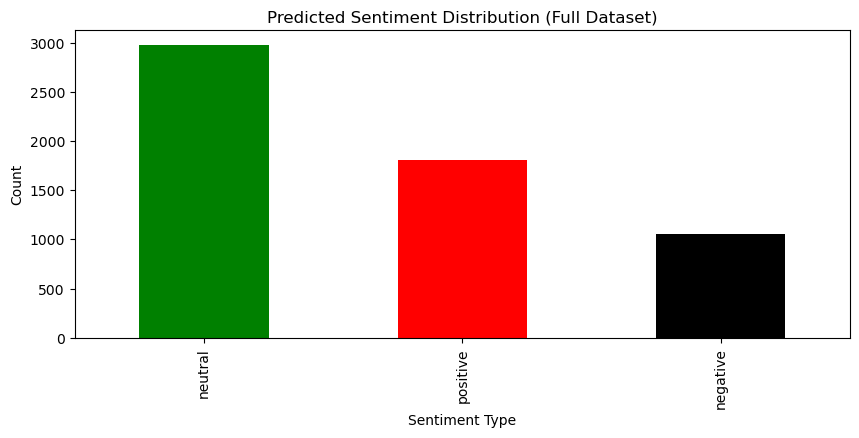

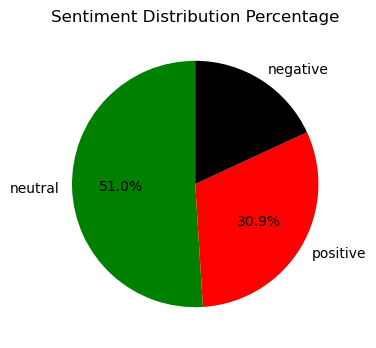

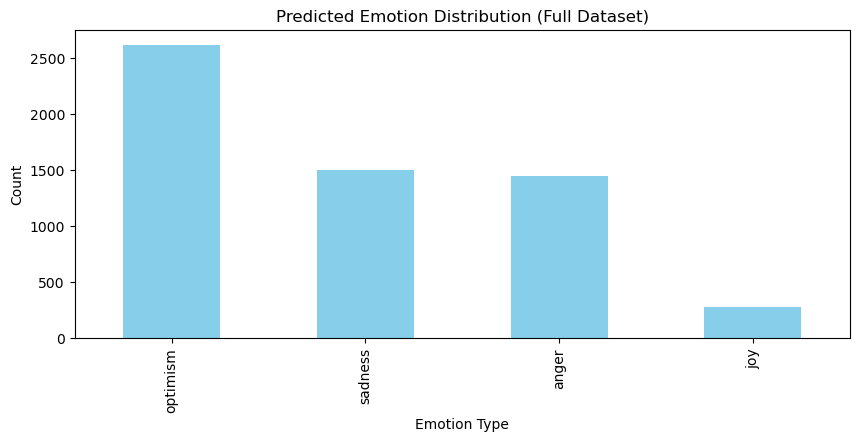

In [2]:
#  Step 1: Import libraries
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
from transformers import pipeline

#  Step 2: Load dataset
data = pd.read_csv("data.csv")
print("✅ Full dataset loaded successfully!")
print(f"Total rows: {len(data)}\n")

# Step 3: Sentiment Analysis using TextBlob
def get_sentiment_score(text):
    return TextBlob(str(text)).sentiment.polarity

def sentiment_label(score):
    if score > 0:
        return "positive"
    elif score < 0:
        return "negative"
    else:
        return "neutral"

# Apply sentiment analysis
data["Predicted_Sentiment_Score"] = data["Sentence"].apply(get_sentiment_score)
data["Predicted_Sentiment_Label"] = data["Predicted_Sentiment_Score"].apply(sentiment_label)                           
# 💬 Step 4: Emotion Analysis using Transformer
print("\n Performing Emotion Analysis — this may take some time...")                                                     

emotion_classifier = pipeline("text-classification", 
                              model="cardiffnlp/twitter-roberta-base-emotion",
                              return_all_scores=False)

def get_emotion(text):
    try:
        result = emotion_classifier(str(text))[0]
        return result["label"]
    except Exception as e:
        return "error"

data["Predicted_Emotion"] = data["Sentence"].apply(get_emotion)

# 🧾 Step 5: Display preview
print("\n🔹 Preview of Combined Sentiment & Emotion Analysis:\n")
print(data.head(5848))

# Display basic info
print("\nDataset Shape:", data.shape)

print("\nSentiment Distribution:")
sentiment_counts = data["Predicted_Sentiment_Label"].value_counts()
print(sentiment_counts)                                      

# Calculate percentages
total = len(data)
sentiment_percentages = (sentiment_counts / total * 100).round(1)
print("\nPercentages:")
print(sentiment_percentages)

# Summary Table
summary = pd.DataFrame({
    "Sentiment": sentiment_counts.index,
    "Count": sentiment_counts.values,
    "Percentage": sentiment_percentages.values
})
print("\nSummary Table:")
print(summary)

#  Step 6: Visualization
plt.figure(figsize=(10, 4))
data["Predicted_Sentiment_Label"].value_counts().plot(kind="bar", color=["green", "red", "black"])
plt.title("Predicted Sentiment Distribution (Full Dataset)")
plt.xlabel("Sentiment Type")
plt.ylabel("Count")
plt.show()
plt.figure(figsize=(10, 4))
total = len(data)
sentiment_percentages = (sentiment_counts / total * 100).round(1).plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    colors=["green", "red", "black"],
     ylabel=''  
)
plt.title("Sentiment Distribution Percentage")
plt.show()

#  Step 7: Optional Emotion Distribution
plt.figure(figsize=(10, 4))
data["Predicted_Emotion"].value_counts().plot(kind="bar", color="skyblue")
plt.title("Predicted Emotion Distribution (Full Dataset)")
plt.xlabel("Emotion Type")
plt.ylabel("Count")
plt.show()

# Step 8: Save final results
data.to_csv("final test 2.csv", index=False)